## M1 조 송경섭 프로젝트
## 제목 : 택시 이용 내역 데이터

### 1. 결측치 판단 및 처리  
             ; 확인 후 결측 행 삭제

In [1]:
# 1) 원본 데이터 불러오기 

import pandas as pd

pd.read_csv('trip_KS.csv')
data = pd.read_csv('trip_KS.csv')
data.info()


<class 'pandas.DataFrame'>
RangeIndex: 22701 entries, 0 to 22700
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   passenger_name         22701 non-null  str    
 1   tpep_pickup_datetime   22701 non-null  str    
 2   tpep_dropoff_datetime  22701 non-null  str    
 3   payment_method         22701 non-null  str    
 4   passenger_count        22701 non-null  int64  
 5   trip_distance          22701 non-null  float64
 6   fare_amount            22698 non-null  float64
 7   tip_amount             22701 non-null  float64
 8   tolls_amount           22701 non-null  float64
dtypes: float64(4), int64(1), str(4)
memory usage: 1.6 MB


In [2]:
# 2) 결측치 확인 : fare_amount 3개 

data.isna().sum()

passenger_name           0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
payment_method           0
passenger_count          0
trip_distance            0
fare_amount              3
tip_amount               0
tolls_amount             0
dtype: int64

In [3]:
# 3) 결측치 상세 확인용 내역 출력

data[data['fare_amount'].isna()]

,passenger_name,tpep_pickup_datetime,tpep_dropoff_datetime,payment_method,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount
52,Benjamin Johnson,04/04/2017 4:22:03 PM,04/04/2017 4:35:30 PM,Cash,1,2.20,NaN,0.0,0.00
189,Maria Ibarra,08/21/2017 12:40:25 PM,08/21/2017 1:12:31 PM,Debit Card,3,15.20,NaN,5.0,0.00
244,Tina Avila,08/09/2017 8:32:09 AM,08/09/2017 9:31:11 AM,Cash,1,15.89,NaN,10.0,5.76


In [4]:
# 4) fare_amount 결측치가 있는 행 제거 및 결과 확인 

data_wo_null = data.dropna(subset=["fare_amount"]).copy()

print("원본 :", data.shape)
print("결측치 제거 :", data_wo_null.shape)
print("결측치 개수 :\n", data_wo_null.isna().sum())
print("\nfare_amount 결측치 개수:", data_wo_null["fare_amount"].isna().sum())

# 5) 결측치 제거 후 'data_wo_null.csv' 파일 이름으로 저장 (인덱스는 파일에 저장하지 않음) 
data_wo_null.to_csv("data_wo_null.csv", index=False, encoding="utf-8-sig")
print("저장 완료: data_wo_null.csv")


원본 : (22701, 9)
결측치 제거 : (22698, 9)
결측치 개수 :
 passenger_name           0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
payment_method           0
passenger_count          0
trip_distance            0
fare_amount              0
tip_amount               0
tolls_amount             0
dtype: int64

fare_amount 결측치 개수: 0
저장 완료: data_wo_null.csv


In [5]:
# 6) 결측치 제거 후 내용 재확인 

import pandas as pd
pd.read_csv('data_wo_null.csv')
data_wo_null.info()
# data.info(data_wo_null.csv)

<class 'pandas.DataFrame'>
Index: 22698 entries, 0 to 22700
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   passenger_name         22698 non-null  str    
 1   tpep_pickup_datetime   22698 non-null  str    
 2   tpep_dropoff_datetime  22698 non-null  str    
 3   payment_method         22698 non-null  str    
 4   passenger_count        22698 non-null  int64  
 5   trip_distance          22698 non-null  float64
 6   fare_amount            22698 non-null  float64
 7   tip_amount             22698 non-null  float64
 8   tolls_amount           22698 non-null  float64
dtypes: float64(4), int64(1), str(4)
memory usage: 1.7 MB


### 2. 이상치 판단 및 처리

In [6]:
data_wo_null.describe()

,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount
count,22698.000000,22698.000000,22698.000000,22698.000000,22698.000000
mean,1.643581,2.912318,13.024009,1.835327,0.312302
std,1.304983,3.651335,13.240074,2.800093,1.398775
min,0.000000,0.000000,-120.000000,0.000000,0.000000
25%,1.000000,0.990000,6.500000,0.000000,0.000000
50%,1.000000,1.610000,9.500000,1.350000,0.000000
75%,2.000000,3.060000,14.500000,2.450000,0.000000
max,36.000000,33.960000,999.990000,200.000000,19.100000


<Axes: xlabel='None', ylabel='passenger_count'>

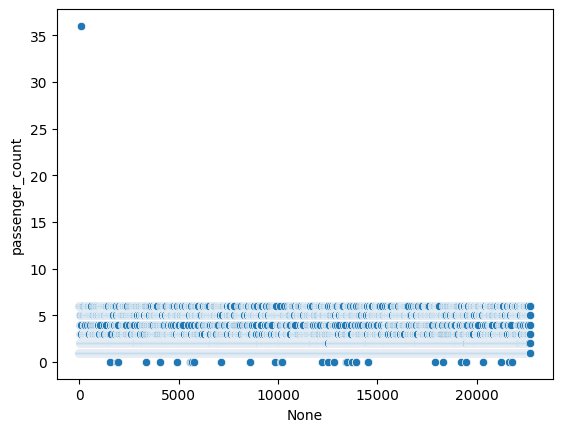

In [9]:
# scatterplot 으로 보기 
# Column 1-1) passenger_count

import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x = data_wo_null.index, y = data_wo_null['passenger_count'])

In [ ]:
# 1-2) 내림차순으로 정렬하여 세부 내역 확인 :이상치로 판단

data_wo_null['passenger_count'].sort_values(ascending = False).head(5)

64       36
49        6
6489      6
11461     6
753       6
Name: passenger_count, dtype: int64

In [ ]:
# index 64 제거

data_wo_null = data_wo_null.drop(index=64, errors="ignore")
data_wo_null['passenger_count'].sort_values(ascending = False).head(5)
# data_wo_null.head(5)


5970     6
13226    6
13228    6
1248     6
11963    6
Name: passenger_count, dtype: int64

<Axes: xlabel='None', ylabel='passenger_count'>

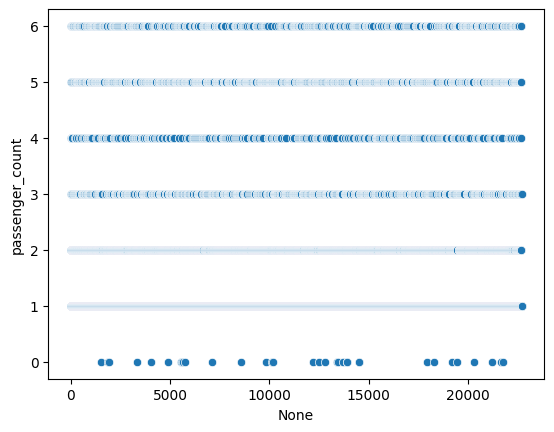

In [ ]:
# Column 1-3) passenger_count, 이상치 제거 후 확인

sns.scatterplot(x = data_wo_null.index, y = data_wo_null['passenger_count'])

<Axes: xlabel='None', ylabel='trip_distance'>

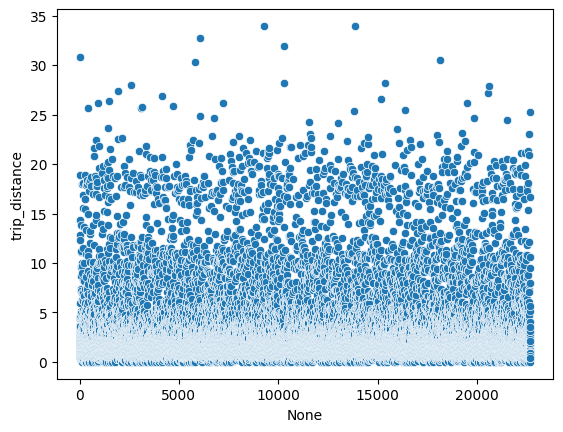

In [ ]:
# scatterplot 으로 보기 
# Column 2-1) trip_distance

sns.scatterplot(x = data_wo_null.index, y = data_wo_null['trip_distance'])

In [ ]:
# 2-2) 내림차순으로 정렬하여 세부 내역 확인 : 이상치 아님으로 판정

data_wo_null['trip_distance'].sort_values(ascending = False).head(10)

9282     33.96
13863    33.92
6066     32.72
10293    31.95
30       30.83
18132    30.50
5794     30.33
15352    28.23
10304    28.20
2594     27.97
Name: trip_distance, dtype: float64

<Axes: xlabel='None', ylabel='fare_amount'>

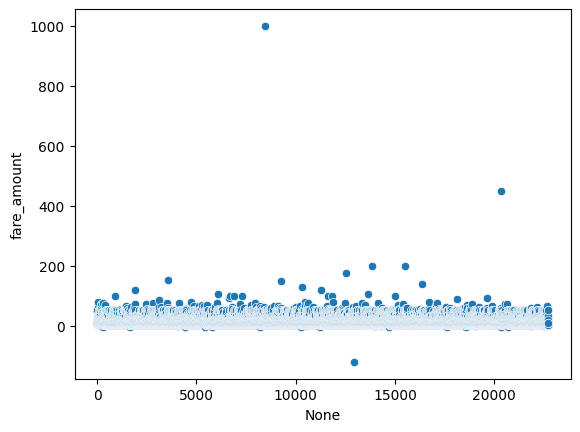

In [ ]:
# scatterplot 으로 보기 
# Column 3-1) fare_amount

sns.scatterplot(x = data_wo_null.index, y = data_wo_null['fare_amount'])

In [ ]:
# 3-2) 내림차순으로 정렬하여 세부 내역 확인 : 이상치이나 그냥 둠

data_wo_null['fare_amount'].sort_values(ascending = False).head(5)

8478     999.99
20314    450.00
13863    200.01
15476    200.00
12513    175.00
Name: fare_amount, dtype: float64

<Axes: xlabel='None', ylabel='tip_amount'>

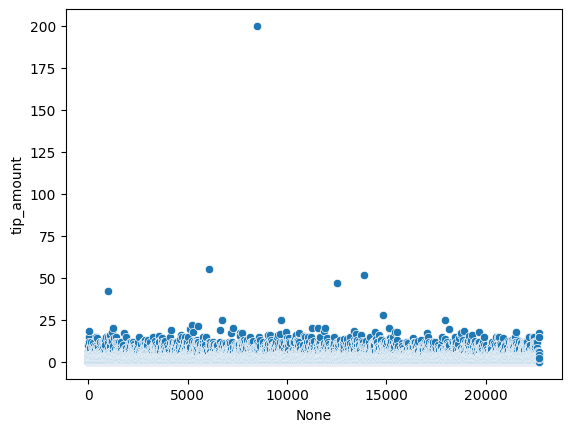

In [ ]:
# scatterplot 으로 보기 
# Column 4-1) tip_amount 

sns.scatterplot(x = data_wo_null.index, y = data_wo_null['tip_amount'])

In [ ]:
# 4-2) 내림차순으로 정렬하여 세부 내역 확인 : 이상치이나 그냥 둠

data_wo_null['tip_amount'].sort_values(ascending = False).head(5)

8478     200.00
6066      55.50
13863     51.64
12513     46.69
986       42.29
Name: tip_amount, dtype: float64

<Axes: xlabel='None', ylabel='tolls_amount'>

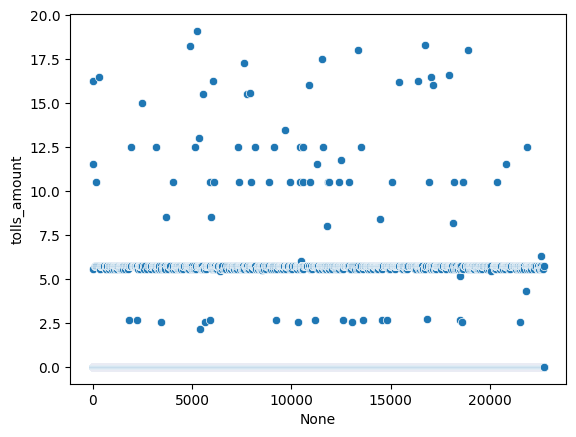

In [ ]:
# scatterplot 으로 보기 
# Column 5-1) tolls_amount 

sns.scatterplot(x = data_wo_null.index, y = data_wo_null['tolls_amount'])

In [ ]:
# 5-2) 내림차순으로 정렬하여 세부 내역 확인 : 이상치 아님

data_wo_null['tolls_amount'].sort_values(ascending = False).head(10)

5273     19.10
16707    18.28
4887     18.26
18890    18.00
13361    18.00
11562    17.50
7629     17.28
17961    16.62
318      16.50
17048    16.50
Name: tolls_amount, dtype: float64

### Step 2-1. 택시 탑승 시간 및 하차 시간 활용

In [ ]:
# 택시의 주행 시간과 주행 거리, 요금 등의 상관 관계 분석

# 음수 제거
data_wo_null = data_wo_null[data_wo_null['trip_duration_min'] >= 0]

# 비정상적 긴 주행 시간 제거
data_wo_null = data_wo_null[data_wo_null['trip_duration_min'] <= 180]

# 상관 관계 분석_기본 데이터 확인
data_wo_null['trip_duration_min'] = (
    data_wo_null['tpep_dropoff_datetime']
    - data_wo_null['tpep_pickup_datetime']
).dt.total_seconds() / 60

data_wo_null['trip_duration_min'].describe()


count    22649.000000
mean        14.325000
std         11.602690
min          0.000000
25%          6.650000
50%         11.166667
75%         18.300000
max        159.316667
Name: trip_duration_min, dtype: float64

In [ ]:
# 상관 관계 분석 준비

import seaborn as sns
import matplotlib.pyplot as plt

corr_cols = [
    'trip_duration_min',
    'trip_distance',
    'fare_amount',
    'tip_amount',
    'tolls_amount',
    'passenger_count'
]

corr_df = data_wo_null[corr_cols]


In [ ]:
# 변수간 상관 관계 분석

corr_matrix = corr_df.corr()
corr_matrix


,trip_duration_min,trip_distance,fare_amount,tip_amount,tolls_amount,passenger_count
trip_duration_min,1.000000,0.153545,0.128345,0.072520,0.084425,0.016888
trip_distance,0.153545,1.000000,0.756467,0.501965,0.622811,0.016512
fare_amount,0.128345,0.756467,1.000000,0.678695,0.513815,0.010474
tip_amount,0.072520,0.501965,0.678695,1.000000,0.422067,-0.009930
tolls_amount,0.084425,0.622811,0.513815,0.422067,1.000000,0.009708
passenger_count,0.016888,0.016512,0.010474,-0.009930,0.009708,1.000000


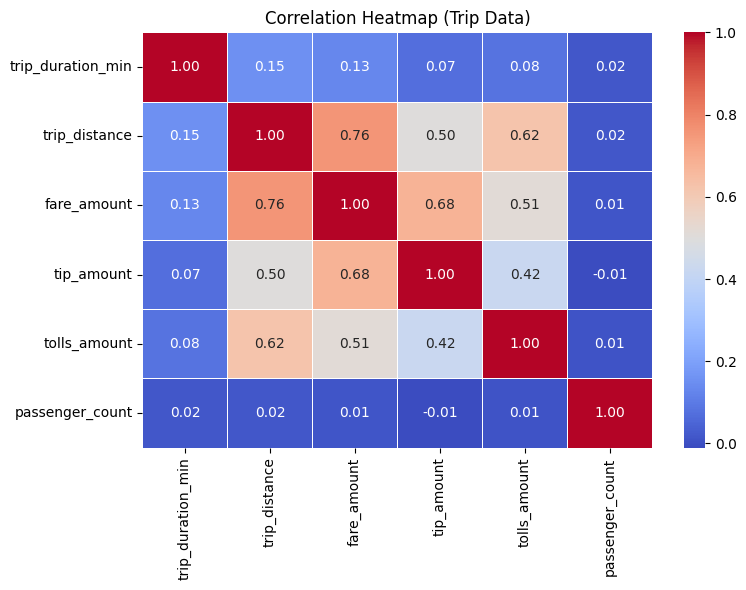

In [ ]:
# 상관 관계 히트맵

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap (Trip Data)")
plt.tight_layout()
plt.show()


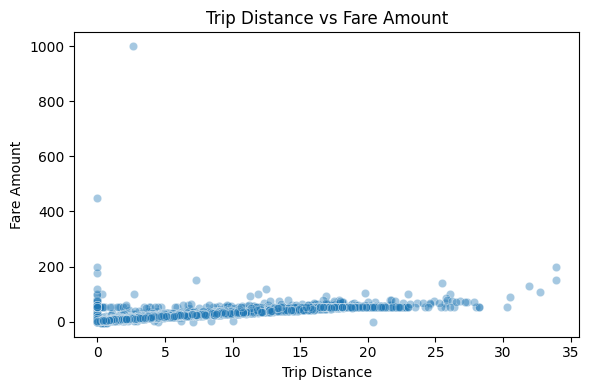

In [ ]:
# 주행 거리와 요금의 산점도 

plt.figure(figsize=(6,4))
sns.scatterplot(
    data=data_wo_null,
    x='trip_distance',
    y='fare_amount',
    alpha=0.4
)
plt.title("Trip Distance vs Fare Amount")
plt.xlabel("Trip Distance")
plt.ylabel("Fare Amount")
plt.tight_layout()
plt.show()


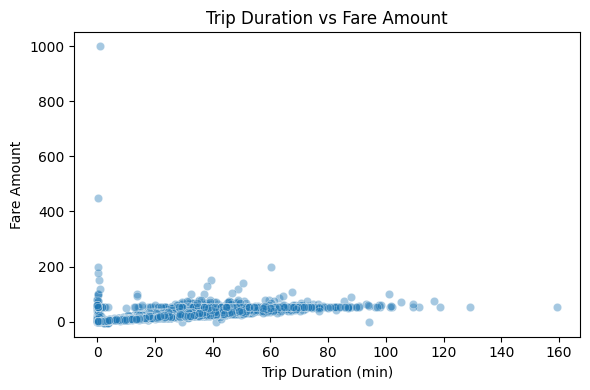

In [ ]:
# 주행 시간과 요금의 산점도


plt.figure(figsize=(6,4))
sns.scatterplot(
    data=data_wo_null,
    x='trip_duration_min',
    y='fare_amount',
    alpha=0.4
)
plt.title("Trip Duration vs Fare Amount")
plt.xlabel("Trip Duration (min)")
plt.ylabel("Fare Amount")
plt.tight_layout()
plt.show()


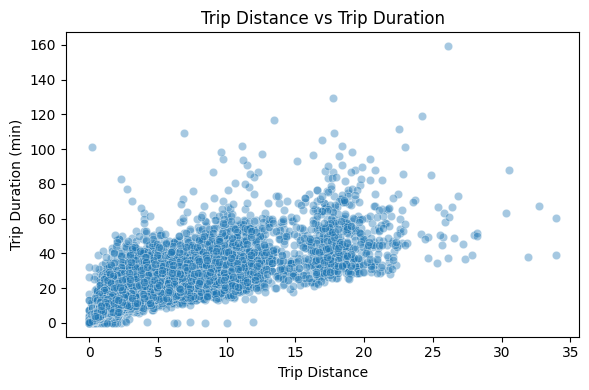

In [ ]:
# 주행 거리와 시간 간의 산점도

plt.figure(figsize=(6,4))
sns.scatterplot(
    data=data_wo_null,
    x='trip_distance',
    y='trip_duration_min',
    alpha=0.4
)
plt.title("Trip Distance vs Trip Duration")
plt.xlabel("Trip Distance")
plt.ylabel("Trip Duration (min)")
plt.tight_layout()
plt.show()


### 결론  :   
###     택시 주행 시간과 이동 거리는 요금과 강한 양의 상관관계를 보이며, 승객 수는 요금에 큰 영향을 미치지 않습니다.

In [ ]:
# 결제 수단 종류 확인 

data_wo_null['payment_method'].value_counts()


payment_method
Cash           11170
Debit Card      5769
Credit Card     5710
Name: count, dtype: int64

### Step 2-2 : Credit Card와 Debit Card를 구분없이 "Card"로 통합

In [ ]:
# 결제 수단 종류 통합, Credit / Debit --> Card

data_wo_null['payment_method_clean'] = (
    data_wo_null['payment_method']
    .replace({
        'Credit Card': 'Card',
        'Debit Card': 'Card'
    })
)

data_wo_null['payment_method_clean'].value_counts()



payment_method_clean
Card    11479
Cash    11170
Name: count, dtype: int64

In [ ]:
# 결제 수단 별 요금 비교

data_wo_null.groupby('payment_method_clean')['fare_amount'].mean()


payment_method_clean
Card    13.084955
Cash    12.948994
Name: fare_amount, dtype: float64